This notebook discusses NRLEE nucleosynthesis via Jupyter technology.  As you read through the text, you can execute the code blocks.  You can change input (for example, choose different axis ranges or scaling or select different species to show in the plots).  You can right-click or control-click on figures to save them.  If your current version gets corrupted, don't worry.  Simply quit and download a new copy from GitHub, or start up a new version on Google Colab.

## Table of Contents:

[Introduction](#introduction)<br/>
[Preliminaries](#preliminaries)<br/>
[Model](#model)<br/>
[Pre-explosion nucleosynthesis](#pre-explosion)<br/>
[Explosive nucleosynthesis](#explosive)<br/>

<a id='introduction'></a>
# Introduction


Here is the anatomy of a NRLEE:
    
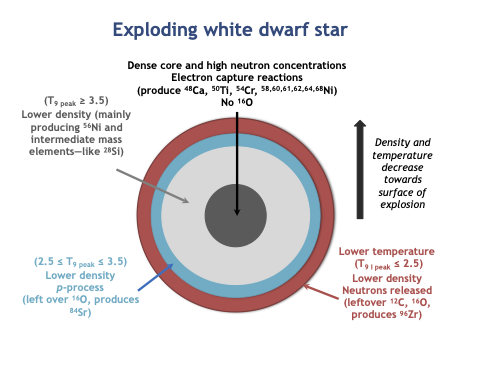

TODO:  obviously more text setting up the idea.

<a id='preliminaries'></a>
# Preliminaries

This notebook explores NRLEE nucleosynthesis via output from a series of single-zone network calculations. We first need to perform some preliminary operations to set up the notebook.

<a id='General'></a>
## General

Here we import packages and download data.  First, import the necessary packages and download the necessary data.

In [1]:
import sys, io, requests
!{sys.executable} -m pip install --quiet wnutils

The next step is to import the package to check for and retrieve the data:

In [2]:
import os.path
from os import path

This notebook uses [wnutils](https://wnutils.readthedocs.io) to analyze the nucleosyntheis [XML](https://www.w3.org/TR/REC-xml/) output, so the next code block imports that package.  It also imports the matplotlib and numpy packages.

In [3]:
import wnutils.xml as wx
import wnutils.multi_xml as mx
import matplotlib.pyplot as plt
import numpy as np

Read in the Solar System abundance data from Lodders from [OSF](https://osf.io/394ws/).  Store the data in a wnutils XML object.

In [4]:
url = 'https://osf.io/j67qa/download'
solar = wx.Xml(io.BytesIO((requests.get(url).content)))

solar_zone = solar.get_zone_data()

<a id='overabundances'></a>
## Overabundances

This section defines routines for computing overabundances.  Radioactive species overabundances are computed relative to the ultimate daughter (supplied by the rp dictionary).

In [5]:
def calc_overabundances(xml, species, rp=None, zone_xpath=""):
    ov = {}
    x = xml.get_mass_fractions(species, zone_xpath=zone_xpath)

    for sp in species:
        if sp in rp:
            rsp = rp[sp]
        else:
            rsp = sp
        tup = xml.get_z_a_state_from_nuclide_name(rsp)
        ov[sp] = x[sp] / solar_zone['0']['mass fractions'][(rsp, tup[0], tup[1])]
        
    return ov

<a id='polytrope'></a>
## Polytrope

This section sets up the packages, data, and routines for computing the polytrope solutions for white dwarf stars.  First, import the necessary packages.

In [6]:
from scipy.integrate import odeint
from scipy.optimize import root_scalar

Now we define the Lane-Emden equation as two first order derivatives.  Also add a tiny amount to the denominator of one term to avoid overflows and take the absolute value of $\theta$ in taking powers because this is a problem for some n values.  In our treatment, where we are only considering physically relevant solutions (with $\theta \geq 0$), this last point is only an issue near the root when we are root finding.  Near the root, the $\theta^n$ term contributes negligibly to the derivative.

In [7]:
def lane_emden(y, x, n):
    theta, dtheta = y
    dydx = [dtheta, -2. * dtheta / (x + 1.e-300) - np.power(np.abs(theta), n)]
    return dydx

Now we set up the root function.  Set a condition to terminate the root finding when the result is within one part in $10^6$ of the true solution.  This is to suppress unnecessary warnings.

In [8]:
def f(x, phi_0, n):
    assert(n > 0 and n < 5)
    y0 = [1., 0.]
    xsol = np.linspace(0, x, 2)
    sol = odeint(lane_emden, y0, xsol, args=(n,))
    result = sol[sol.shape[0]-1, 0] - phi_0
    if abs(result) < 1.e-6:
        result = 0
    return result

<a id='model'></a>
# Model

In this section, you choose the model for study.

In [9]:
model = 'model1'

The following code block next checks whether the data for the model exist locally, and, if not, retrieves and unpacks them.  If you would like to suppress the download progress, add a *-s* to the curl command.

In [10]:
if not path.exists(model):
    !curl -o model.tar.gz -J -L https://osf.io/867ce/download
    !tar zxf model.tar.gz

The next step is to read in the data from the various calculations for the model.

In [11]:
h = wx.Xml(model + '/h_burn/out.xml')
he = wx.Xml(model + '/he_burn/out.xml')
sproc = wx.Xml(model + '/s-process/out.xml')
exp_tau = wx.Xml(model + '/s-process/exp_tau.xml')
full = wx.Xml(model + '/expl/full.xml')

<a id='pre-explosion'></a>
# Pre-explosion nucleosynthesis

With the data now downloaded, it is now possible to explore the nucleosynthesis before the explosion.

## Hydrogen burning

The first nucleosynthesis stage in the star's life was hydrogen burning.  This was modeled at constant temperature and density with initial solar composition, as given by [Lodders](https://ui.adsabs.harvard.edu/abs/2003ApJ...591.1220L/abstract).  The conditions are printed in the next cell.

In [12]:
props = h.get_properties_as_floats(['time', 't9', 'rho'])
print('For the calculation, the duration, temperature, and density were:')
print('   time (Gyr) = {0:.2e}'.format(props['time'][len(props['time'])-1] / 3.15e17))
print('   T (K) = {:.2e}'.format(props['t9'][len(props['t9'])-1] * 1.e9))
print('   mass density (g/cc) = {:.2e}'.format(props['rho'][len(props['rho'])-1]))

For the calculation, the duration, temperature, and density were:
   time (Gyr) = 3.00e+00
   T (K) = 2.00e+07
   mass density (g/cc) = 2.00e+01


In hydrogen burning, the initial $^1$H burns to $^4$He.  For stars greater than about 1.3 times the mass of the Sun, this occurs via [CNO cycling](https://en.wikipedia.org/wiki/CNO_cycle).  Note that the mass fraction of a species is the fraction of the total mass of the system that is in that species.  It is thus the grams of that species per gram of material.  Core hydrogen burning occurs largely non-convectively in stars that leave behind white dwarf remnants.  Typically about 10% of the star (by mass) undergoes core hydrogen burning.

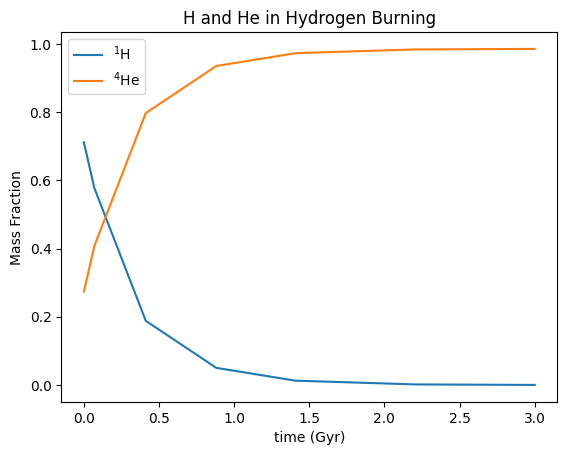

In [13]:
species = ['h1', 'he4']
h.plot_mass_fractions_vs_property('time', species, xfactor = 3.15e17, xlabel='time (Gyr)',
                                  use_latex_names = True, title='H and He in Hydrogen Burning')

## Helium burning

Once the star exhausts its core hydrogen, it contracts and heats up.  Shell hydrogen burning ignites in the hydrogen-rich layers outside the hydrogen exhausted core.  This burning adds to the size of the helium-rich core.  Evenutally, helium burning ignites in the core.  For the present calculation, this burning stage was again modeled with constant temperature and density, and the conditions are printed in the next cell.

In [14]:
props = he.get_properties_as_floats(['time', 't9', 'rho'])
print('For the calculation, the duration, temperature, and density were:')
print('   time (yr) = {0:.2e}'.format(props['time'][len(props['time'])-1] / 3.15e7))
print('   T (K) = {:.2e}'.format(props['t9'][len(props['t9'])-1] * 1.e9))
print('   mass density (g/cc) = {:.2e}'.format(props['rho'][len(props['rho'])-1]))

For the calculation, the duration, temperature, and density were:
   time (yr) = 1.00e+05
   T (K) = 2.00e+08
   mass density (g/cc) = 1.00e+03


Helium burning occurs via the [triple-alpha process](https://en.wikipedia.org/wiki/Triple-alpha_process).  It creates $^{12}$C and $^{16}$O from the initial $^4$He.

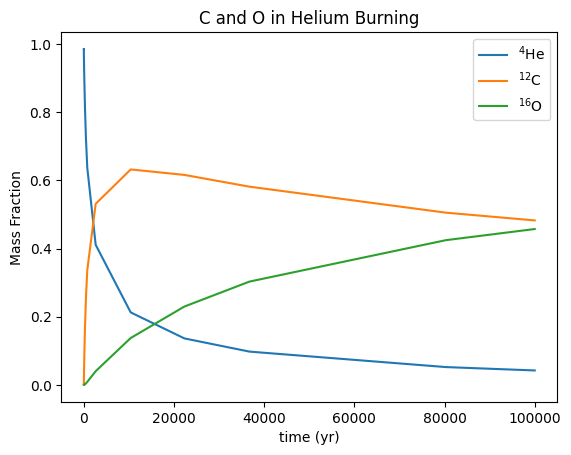

In [15]:
species = ['he4', 'c12', 'o16']
he.plot_mass_fractions_vs_property('time', species, xfactor = 3.15e7, xlabel='time (yr)',
                                   use_latex_names = True, title = 'C and O in Helium Burning')

Helium burning creates a carbon/oxygen core in the star.  If the core becomes [degenerate](https://en.wikipedia.org/wiki/Degenerate_matter#Degenerate_gases) at this stage, it is able to sustain itself against further gravitational contraction without further nuclear burning.  The reason is that radiation loss normally leads to a loss of energy from the core, which means the pressure decreases.  Nuclear burning releases energy and maintains the necessary pressure.  For degenerate matter, however, the pressure is simply maintained by the fact that no two electrons can exist in the same quantum mechanical state (the [Pauli exclusion principle](https://en.wikipedia.org/wiki/Pauli_exclusion_principle)).  At high density, this fact allows there to be strong pressure even at low temperature.



## S process

Outside the carbon/oxygen core, helium-rich matter exists and can undergo helium burning.  The ashes of this burning ($^{12}$C and $^{16}$O) settle onto the core and increase the core's mass.  The burning is in fact a complicated and alternating interplay of shell helium burning and shell hydrogen burning outside the helium burning, with mixing occurring between the various shell burnings.  This is the burning that occurs during the star's life on the [asymptotic giant branch](https://en.wikipedia.org/wiki/Asymptotic_giant_branch) (AGB).  During this phase, [s-processing](https://en.wikipedia.org/wiki/S-process) can occur.

The present calculation modeled s-process nucleosynthesis by running the ashes of helium burning at constant temperature, density, and neutron density, which are printed in the next cell.

In [16]:
props = sproc.get_properties_as_floats(['time','t9', 'rho'])
x_n = sproc.get_mass_fractions(['n'])['n']
n_n = x_n[len(x_n)-1] * props['rho'][len(props['rho'])-1] * 6.022e23
print('For the calculation, the duration, temperature, mass density, and neutron density were:')
print('   time (yr) = {0:.2e}'.format(props['time'][len(props['time'])-1] / 3.15e7))
print('   T (K) = {:.2e}'.format(props['t9'][len(props['t9'])-1] * 1.e9))
print('   mass density (g/cc) = {:.2e}'.format(props['rho'][len(props['rho'])-1]))
print('   neutron density (per cc) = {:.2e}'.format(n_n))

For the calculation, the duration, temperature, mass density, and neutron density were:
   time (yr) = 1.00e+05
   T (K) = 2.50e+08
   mass density (g/cc) = 1.00e+03
   neutron density (per cc) = 1.00e+08


A convenient parameter for discussion of the evolution of the neutron captures is the neutron exposure $\\tau$.  It is mathematically defined as $\tau(t) = \int_0^t n_n(t') v_T(t') dt'$, where $n_n(t)$ is the neutron density (number of neutrons per cubic centimeter) at time $t$ and $v_T(t)$ is the thermal velocity of the neutrons at time $t$.  Physically, the exposure is the total number of neutrons that pass through an area in duration from time 0 to $t$.  For s-process studies, it is convenient to use the units inverse millibarns, where a millibarn, 1/1000 of a [barn](https://en.wikipedia.org/wiki/Nuclear_cross_section), has units $10^{-27}$ cm$^2$.  The following code block shows the evolution of the neutron exposure in the calculation as a function of time.  Since the neutron density and temperature were held constant in the calculation, the exposure rises linearly with the time.

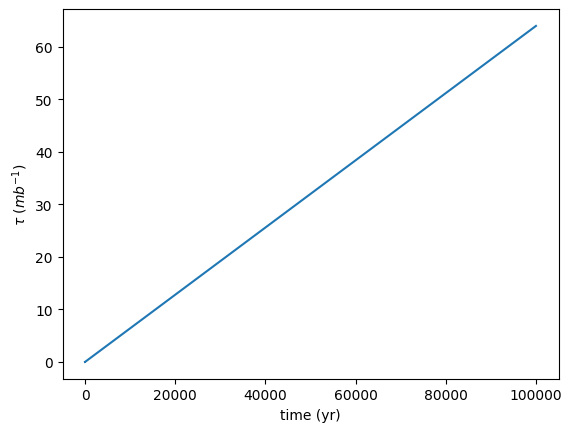

In [17]:
sproc.plot_property_vs_property('time', ('exposure','n'), xfactor = 3.15e7, xlabel='time (yr)',
                                ylabel='$\\tau\ (mb^{-1})$')

The ensemble of nuclei undergoing s-process nucleosynthesis does not see a single neutron exposure but, because of the complicated interplay of hydrogen and helium shell burning in the AGB star, experiences rather a distribution $\rho(\tau)$ of such exposures.  Early [studies](https://ui.adsabs.harvard.edu/abs/1974ApJ...193..397C/abstract) used an exponential distribution of exposures such that $\rho(\tau) = \frac{1}{\tau_0} e^{-\tau/\tau_0}$, where $\tau_0$ is the mean exposure.  For such a distribution, most nuclei see little exposure and a smaller fraction of nuclei see larger exposures.  Those early studies found that an exponential distribution with $\tau_0 = 0.3\ mb^{-1}$ fits the solar s-process abundance distribution fairly well.  The current model uses such a distribution, and the next code block shows the abundance distribution that results when the abundances for the model are weighted by this distribution.

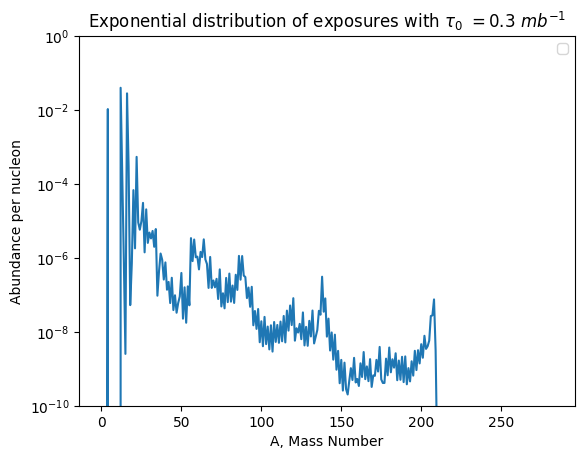

In [18]:
exp_tau.plot_abundances_vs_nucleon_number(ylim=[1.e-10,1], xlabel='A, Mass Number', ylabel='Abundance per nucleon',\
                                          yscale='log', title = 'Exponential distribution of exposures with $\\tau_0\ = 0.3\ mb^{-1}$',
                                          legend="")

Plot outer layers.   TODO:  add discussion.  Add single zone calculations (animations?) to show production of 96Zr and 84Sr.

<a id='explosive'></a>

# Explosive nucleosynthesis

The exploding white dwarf star was simulated by taking an initial composition from the s-process calculations and considering that composition at a variety of initial densities.  The matter was imagined to be heated to an initial temperature that was a function of the initial density and then allowed to expand and cool on an exponential timescale.  The first section in what follows shows the results from these calculations.  The second section applies the Lane-Emden equations to create a simple model of a white dwarf star with the resulting nucleosynthesis yields.

## Initial density

Retrieve key properties from a chosen density range from the full XML input.  The default is all zones, but the commented out line shows how to select a more limited set that would ultimately represent a white dwarf star with a lower central density.

In [19]:
zone_xpath = ""
#zone_xpath = "[optional_properties/property[@name = 'rho_0'] < 2.0e+09]"

props = full.get_properties_as_floats(['rho_0', 't9_0'], zone_xpath=zone_xpath)

Retrieve the initial (peak) temperature versus initial density and plot them against each other.

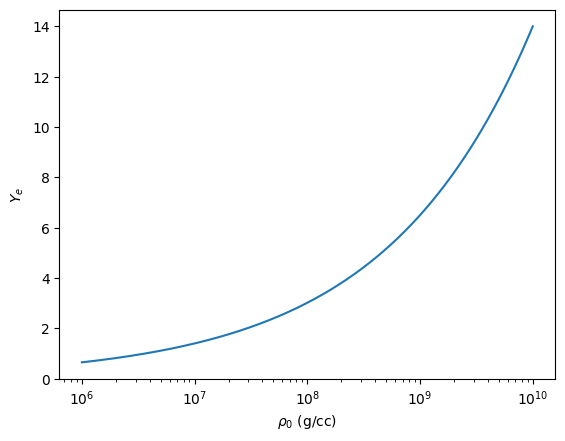

In [20]:
plt.plot(props['rho_0'], props['t9_0'])
plt.xscale('log')
plt.xlabel('$\\rho_0$ (g/cc)')
plt.ylabel('$Y_e$')
plt.show()

Plot the final electron fraction $Y_e$ as a function of the initial density.  At high density, electron-capture reactions are sufficiently fast during the explosion that $Y_e$ reduces down to values well below the initial value near 0.5.

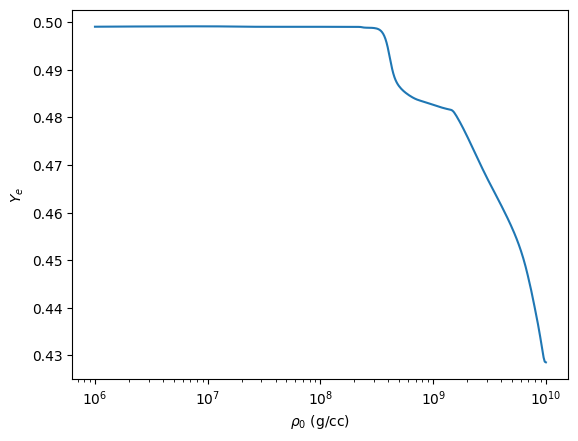

In [21]:
y = full.get_all_abundances_in_zones(zone_xpath=zone_xpath)
ye = np.sum(np.dot(np.swapaxes(y, 1, 2), np.arange(y.shape[1])), axis=1)
plt.plot(props['rho_0'], ye)
plt.xscale('log')
plt.xlabel('$\\rho_0$ (g/cc)')
plt.ylabel('$Y_e$')
plt.show()

Choose species to study. Also, here define a daughters dictionary to permit the overabundance code to compute overabundance of a radioactive species relative to its ultimate daughter. The dictionary can include species other than the ones chosen for study, but any radioactivity in the species list must have an entry in the daughters dictionary.  Also retrieve the species mass fractions and latex names for later use.

In [22]:
species = ['ca40', 'ca41', 'ca42', 'ca43', 'ca44', 'ca46', 'ca48']
daughters = {'ca41': 'k41', 'fe60': 'ni60'}
lnames = full.get_latex_names(species)
x = full.get_mass_fractions(species, zone_xpath=zone_xpath)

Plot mass fractions as a function of the initial density.

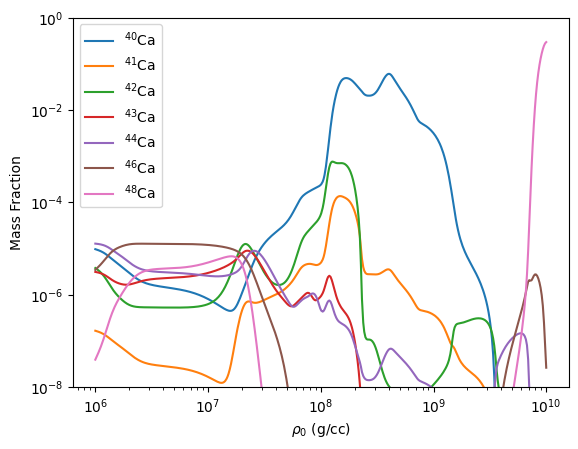

In [23]:
for sp in species:
    plt.plot(props['rho_0'], x[sp], label=lnames[sp])
    
plt.xscale('log')    
plt.yscale('log')
plt.ylim([1.e-8,1])
plt.xlabel('$\\rho_{0}$ (g/cc)')
plt.ylabel('Mass Fraction')
plt.legend()
plt.show()

Plot the overabundances (abundance relative to the Solar abundance) as a function of the initial density.

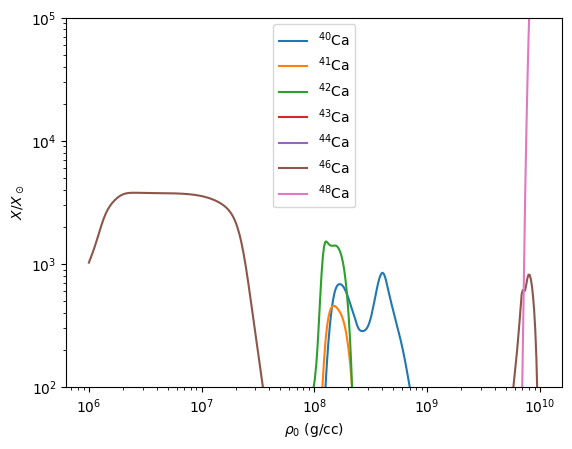

In [24]:
ov = calc_overabundances(full, species, rp = daughters, zone_xpath = zone_xpath)
for sp in ov:
    plt.plot(props['rho_0'], ov[sp], label=lnames[sp])
    
plt.xscale('log')    
plt.yscale('log')
plt.ylim([100,1.e5])
plt.xlabel('$\\rho_{0}$ (g/cc)')
plt.ylabel('$X / X_\\odot$')
plt.legend()
plt.show()

## Convert to a white dwarf model

Convert the initial densities to a white-dwarf star model by applying a polytropic solution (a solution to the Lane-Emden equation).  Choose the total mass in solar masses (1.4 Solar masses is the typical Chandrasekhar limit, which is the theoretical maximum limit on a stable white dwarf star mass) and the polytropic index, which can range $0 < n < 5$.  The smaller $n$ is, the more uniform the density is in the model.  The central density is determined from the XML input.  We store the densities and flip them (to go from high to low) to align them with interior mass coordinates later.  If you would like to change the central density of the white dwarf model, change the *zone_xpath* above.

In [25]:
M = 1.4
n = 3

Compute the interior mass coordinates based on the chosen index and total mass.  The central density is determined from the XML input.  We store the densities and flip them to align them with the interior mass.  Also compute shell thicknesses.

In [26]:
rhos = np.flip(props['rho_0'])
rho_c = rhos[0]

Ms = []
dM = []

sol = root_scalar(f, args=(0, n), x0 = 0, x1 = 1)
xsi_1 = sol.root
x = np.linspace(0, xsi_1, 101)
msol = odeint(lane_emden, [1., 0.], x, args=(n,))
dphi_1 = msol[msol.shape[0]-1, 1]

for r in rhos:
    phi_0 = (r / rho_c)**(1./n)
    sol = root_scalar(f, args=(phi_0, n), x0 = 0, x1 = 1)
    xsi = sol.root
    x = np.linspace(0, xsi, 101)
    msol = odeint(lane_emden, [1., 0.], x, args=(n,))
    dphi = msol[msol.shape[0]-1, 1]
    Ms.append(M * xsi**2 * dphi / (xsi_1**2 * dphi_1))
    
Ms[0] = 0  # Reset to avoid slightly non-zero value due to numerical inaccuracies.

for i in range(len(Ms)-1):
    dM.append(Ms[i+1] - Ms[i])
    
dM.append(M - Ms[len(Ms)-1])

Plot the density as a function of mass.

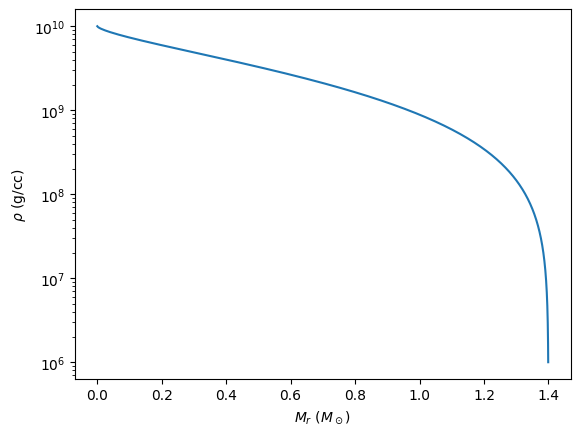

In [27]:
plt.plot(Ms, rhos)
plt.xlabel('$M_r\\ (M_\\odot)$')
plt.ylabel('$\\rho$ (g/cc)')
plt.yscale('log')
plt.show()

Plot the final electron fraction $Y_e$ as a function of the interior mass coordinate.  The inner regions experience, owing to their high densities, experience the most electron capture and so have the lowest final $Y_e$ values.

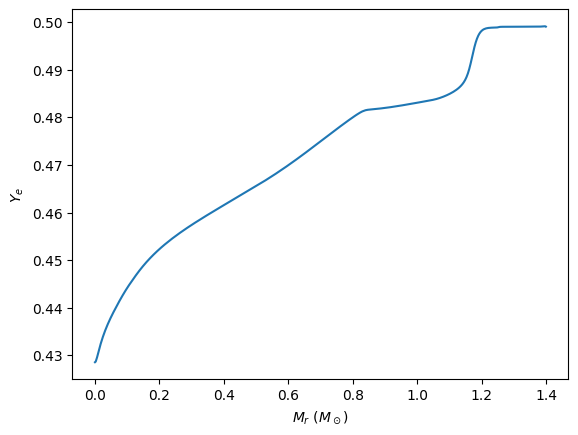

In [28]:
plt.plot(Ms, np.flip(ye))
plt.xlabel('$M_r\\ (M_\\odot)$')
plt.ylabel('$Y_e$')
plt.show()

Choose species to study.  Also, here define a daughters dictionary to permit the overabundance code to compute overabundance of a radioactive species relative to its ultimate daughter.  The dictionary can include species other than radioactive ones chosen for study, but any radioactivity in the *species* list must have an entry in the *daughters* dictionary.

In this cell, we also create the latex names for the species and flip the species arrays to align them with the masses.

In [29]:
species = ['ti44', 'ti46', 'ti47', 'ti48', 'ti49', 'ti50']
daughters = {'ti44': 'ca44', 'fe60': 'ni60'}

lnames = full.get_latex_names(species)

x = full.get_mass_fractions(species, zone_xpath = zone_xpath)
xf = {}
for sp in species:
    xf[sp] = np.flip(x[sp])

Plot the mass fractions as a function of the interior mass coordinate.

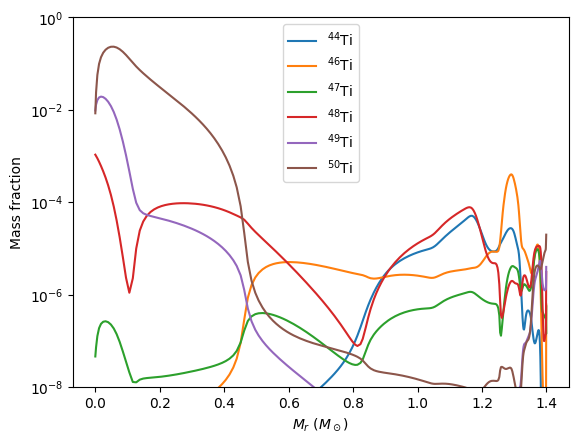

In [30]:
for sp in xf:
    plt.plot(Ms, xf[sp], label=lnames[sp])
    
plt.yscale('log')
plt.ylim([1.e-8,1])
plt.xlabel('$M_r\\ (M_\\odot)$')
plt.ylabel('Mass fraction')
plt.legend()
plt.show()

Now plot the overabundances as a function of interior mass.

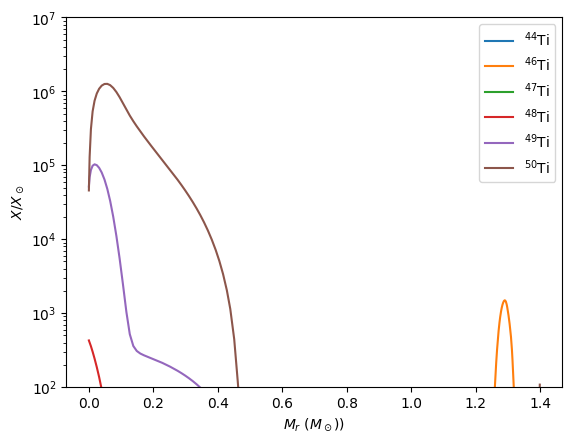

In [31]:
ov = calc_overabundances(full, species, rp = daughters, zone_xpath = zone_xpath)
for sp in ov:
    plt.plot(Ms, np.flip(ov[sp]), label=lnames[sp])
    
plt.yscale('log')
plt.ylim([100,1.e7])
plt.xlabel('$M_r\\ (M_\\odot)$)')
plt.ylabel('$X / X_\\odot$')
plt.legend()
plt.show()

Save the mass fractions as a function of mass coordinate $M_r$ and shell mass $dM$ (in Solar masses) in file *my_file*.  Change the name from the default *my_file.txt* according to your purposes.  The file will be written in the local directory.  On Google Colab, click on the file tab on the far left and download.  To also print out the data, change *print_out* to *True*.

In [32]:
my_file = 'my_file.txt'

print_out = False

f = open(my_file, 'w')

f.write('Mr\t' + 'dM\t' + '\t'.join(species) + '\n')

for i in range(len(Ms)):
    x = []
    for sp in xf:
        x.append('{:.4e}'.format(xf[sp][i]))
        
    f.write('{:.4e}'.format(Ms[i]) + '\t' + '{:.4e}'.format(dM[i])+ '\t' + '\t'.join(x) + '\n')
    
f.close()
    
if print_out:
    f = open(my_file, 'r')
    for line in f:
        print(line)